# Algorithmic Fairness and Classification
# COMPAS Recidivism Dataset Analysis

## Overview

In this homework, you will:
1. Load and explore the COMPAS (Correctional Offender Management Profiling for Alternative Sanctions) dataset
2. Preprocess the data and handle missing values
3. Build classification models using Logistic Regression and Random Forest
4. Evaluate model performance using various metrics including:
   - Accuracy
   - Sensitivity (True Positive Rate / Recall)
   - Specificity (True Negative Rate)
   - Precision (Positive Predictive Value)
   - False Positive Rate
   - False Negative Rate
   - Confusion Matrix
   - ROC Curve and AUC

---

## Part 0: Setup and Imports

Run the following cell to install and import necessary libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score, precision_score, recall_score
)

# random seed for reproducibility
np.random.seed(42)

---

## Part 1: Data Loading and Exploration (5 points)

### 1.1 Load the COMPAS Dataset

The COMPAS dataset contains information about defendants and their recidivism outcomes. Load the dataset from the provided URL or local file.

In [2]:
# Load the COMPAS dataset
# Data source: ProPublica's COMPAS Analysis
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

# TODO: Load the data into a Pandas DataFrame

df = pd.read_csv(url)

# Displaying the first few sets of data 
print(df.head())

   id                name   first         last compas_screening_date   sex  \
0   1    miguel hernandez  miguel    hernandez            2013-08-14  Male   
1   3         kevon dixon   kevon        dixon            2013-01-27  Male   
2   4            ed philo      ed        philo            2013-04-14  Male   
3   5         marcu brown   marcu        brown            2013-01-13  Male   
4   6  bouthy pierrelouis  bouthy  pierrelouis            2013-03-26  Male   

          dob  age          age_cat              race  ...  v_decile_score  \
0  1947-04-18   69  Greater than 45             Other  ...               1   
1  1982-01-22   34          25 - 45  African-American  ...               1   
2  1991-05-14   24     Less than 25  African-American  ...               3   
3  1993-01-21   23     Less than 25  African-American  ...               6   
4  1973-01-22   43          25 - 45             Other  ...               1   

   v_score_text  v_screening_date  in_custody  out_custody  pr

### 1.2 Filtering the Data
For the purpose of this exercise, we will just consider a small subset of relevant features:

**Features**:
- `age`: Age of the individual at the time of COMPAS assessment (in years)
- `sex`: Biological sex of the individual (Male, Female)
- `race`: Self-identified race of the individual (e.g., African-American, Caucasian)
- `priors_count`: Number of prior criminal charges recorded before the current offense
- `c_charge_degree`: Severity of the current charge (F="Felony", M="Misdemeanor")

**Target**:
- `two_year_recid`: Binary indicator of whether the individual was rearrested for a new offense within two years of the COMPAS assessment
    * 1 = Recidivated within two years
    * 0 = Did not recidivate

In [3]:
# TODO: filter the dataset to just include the specified features

features = ['age', 'sex', 'race', 'priors_count', 'c_charge_degree', 'two_year_recid']

filtered_df = df[features]

print(filtered_df.head())

   age   sex              race  priors_count c_charge_degree  two_year_recid
0   69  Male             Other             0               F               0
1   34  Male  African-American             0               F               1
2   24  Male  African-American             4               F               1
3   23  Male  African-American             1               F               0
4   43  Male             Other             2               F               0


### 1.3 Exploratory Data Analysis

**Task:** Briefly examine the dataset structure (i.e. number of entries) and check for missing values:

In [4]:
# TODO: Display basic information about the dataset

filtered_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              7214 non-null   int64
 1   sex              7214 non-null   str  
 2   race             7214 non-null   str  
 3   priors_count     7214 non-null   int64
 4   c_charge_degree  7214 non-null   str  
 5   two_year_recid   7214 non-null   int64
dtypes: int64(3), str(3)
memory usage: 462.8 KB


In [5]:
# TODO: Check for missing values
filtered_df.isnull().any()

age                False
sex                False
race               False
priors_count       False
c_charge_degree    False
two_year_recid     False
dtype: bool

### 1.4 Visualize Target Distribution

**Task:** Create visualizations showing:
1. Distribution of recidivism (`two_year_recid`)
2. Recidivism rates by race

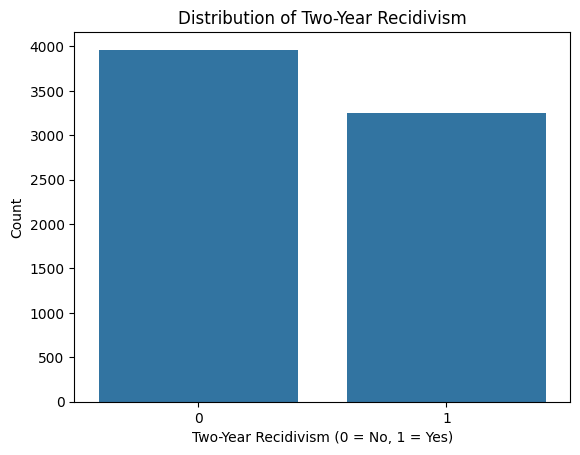

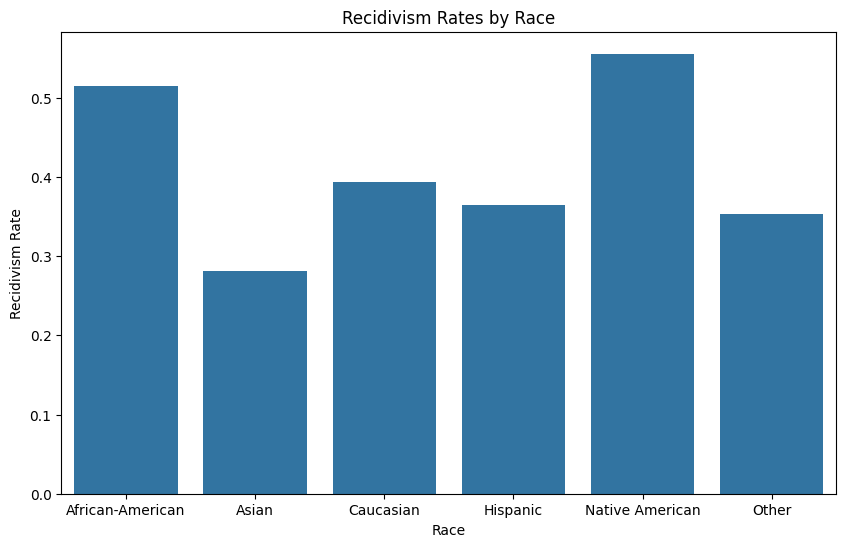

In [6]:
# Plot 1: Overall recidivism distribution
# TODO: Fill in the code to show overall recidivism distribution
sns.countplot(x='two_year_recid', data=filtered_df)
plt.title('Distribution of Two-Year Recidivism')
plt.xlabel('Two-Year Recidivism (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Plot 2: Recidivism by race
# TODO: Fill in the code to show recidivism rates by race
rate_race = filtered_df.groupby('race')['two_year_recid'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='race', y='two_year_recid', data=rate_race)
plt.title('Recidivism Rates by Race')
plt.xlabel('Race')
plt.ylabel('Recidivism Rate')
plt.show()


---

## Part 2: Data Preprocessing (10 points)



### 2.1 Encode Features

**Task:**
Encode the features into the appropriate data type for modeling. For example, `age` is a numeric type, and `sex` should be encoded as binary or categorical feature. Don't forget to encode the target as well!

In [7]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# TODO: Encode the features and target for modeling
# print(filtered_df.columns)

numeric_features = ['age', 'priors_count']
categorical_features = ['sex', 'race', 'c_charge_degree']  

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first')  

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])  

### 2.2 Train-Test Split

**Task:** Split the data into training (70%) and testing (30%) sets. Feel free to use [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) or write your own function.

In [8]:
from sklearn.model_selection import train_test_split

# TODO: Separate features and target
X= preprocessor.fit_transform(filtered_df.drop(columns=['two_year_recid']))
y = filtered_df['two_year_recid'].values

# TODO: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7, stratify=y, random_state=42)

print(X_train.shape)
print(X_test.shape)

(5049, 9)
(2165, 9)


---

## Part 3: Model Training (15 points)

### 3.1 Logistic Regression

**Task:** Train a Logistic Regression model

In [9]:
from sklearn.linear_model import LogisticRegression

# TODO: Create Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))


Train accuracy: 0.6743909685086156
Test accuracy: 0.6697459584295612


### 3.2 Random Forest

**Task:** Train a Random Forest classifier.

In [10]:
from sklearn.ensemble import RandomForestClassifier

# TODO: Create Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Test Accuracy:", rf.score(X_test, y_test))
print("Train Accuracy:", rf.score(X_train, y_train))

Test Accuracy: 0.6286374133949192
Train Accuracy: 0.8280847692612399


---

## Part 4: Model Evaluation (20 points)

### 4.1 Evaluation Function

You will use the function below to evaluate your fitted models on the train and test sets.

In [11]:
def calculate_metrics(y_true, y_pred, y_pred_proba=None):
    """
    Calculate comprehensive classification metrics.

    Parameters:
    - y_true: True labels
    - y_pred: Predicted labels
    - y_pred_proba: Predicted probabilities (optional, for AUC)

    Returns:
    - Dictionary with all metrics
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)

    # Sensitivity (Recall / True Positive Rate)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Specificity (True Negative Rate)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Precision (Positive Predictive Value)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # False Positive Rate
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    # False Negative Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    # AUC (if probabilities provided)
    auc_score = None
    if y_pred_proba is not None:
        auc_score = roc_auc_score(y_true, y_pred_proba)

    return {
        'Accuracy': accuracy,
        'Sensitivity (TPR/Recall)': sensitivity,
        'Specificity (TNR)': specificity,
        'Precision (PPV)': precision,
        'False Positive Rate': fpr,
        'False Negative Rate': fnr,
        'AUC': auc_score,
        'Confusion Matrix': cm,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    }

### 4.2 Evaluate All Models

**Task:** Calculate metrics for the two models on both training and test sets.

In [12]:
# TODO: Evaluate each model
# Logistic Regression - Test
log_test_metrics = calculate_metrics(y_test, model.predict(X_test), model.predict_proba(X_test)[:, 1])
print("Logistic Regression - Test Metrics:", log_test_metrics)


# Logistic Regression - Train
log_train_metrics = calculate_metrics(y_train, model.predict(X_train), model.predict_proba(X_train)[:, 1])
print("Logistic Regression - Train Metrics:", log_train_metrics)


# Random Forest - Test
rf_test_metrics = calculate_metrics(y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1])
print("Random Forest - Test Metrics:", rf_test_metrics)

# Random Forest - Train
rf_train_metrics = calculate_metrics(y_train, rf.predict(X_train), rf.predict_proba(X_train)[:, 1])
print("Random Forest - Train Metrics:", rf_train_metrics)


Logistic Regression - Test Metrics: {'Accuracy': 0.6697459584295612, 'Sensitivity (TPR/Recall)': np.float64(0.5563524590163934), 'Specificity (TNR)': np.float64(0.7628259041211102), 'Precision (PPV)': np.float64(0.6581818181818182), 'False Positive Rate': np.float64(0.23717409587888982), 'False Negative Rate': np.float64(0.44364754098360654), 'AUC': 0.7165935349997932, 'Confusion Matrix': array([[907, 282],
       [433, 543]]), 'TP': np.int64(543), 'TN': np.int64(907), 'FP': np.int64(282), 'FN': np.int64(433)}
Logistic Regression - Train Metrics: {'Accuracy': 0.6743909685086156, 'Sensitivity (TPR/Recall)': np.float64(0.5621978021978022), 'Specificity (TNR)': np.float64(0.7664023071377073), 'Precision (PPV)': np.float64(0.6637259989621173), 'False Positive Rate': np.float64(0.2335976928622927), 'False Negative Rate': np.float64(0.4378021978021978), 'AUC': 0.7244469445478818, 'Confusion Matrix': array([[2126,  648],
       [ 996, 1279]]), 'TP': np.int64(1279), 'TN': np.int64(2126), 'FP':

### 4.3 Confusion Matrices

**Task:** Visualize confusion matrices for the two models on the test set.

In [13]:
# TODO: Create confusion matrix plots
cm_log = confusion_matrix(y_test, model.predict(X_test))
cm_rf = confusion_matrix(y_test, rf.predict(X_test))


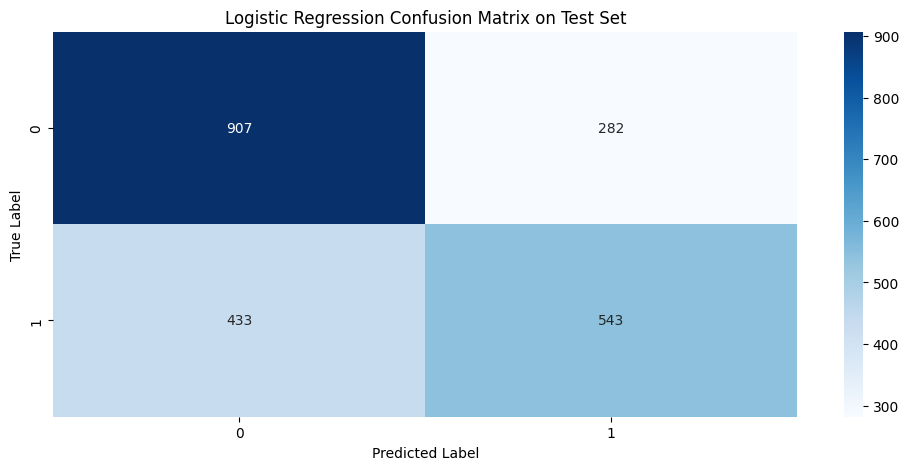

In [14]:
# Logistic Regression Confusion Matrix
plt.figure(figsize=(12, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

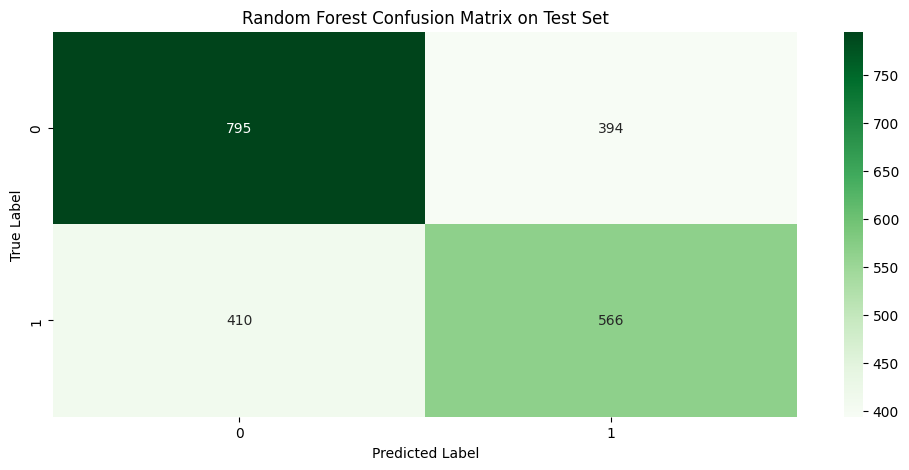

In [15]:
# Random Forest Confusion Matrix
plt.figure(figsize=(12, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### 4.4 ROC Curves and AUC

**Task:** Plot ROC curves for the two models and compare their AUC scores.

In [16]:
# TODO: Plot ROC curves
# Logistic Regression probabilities
log_probs = model.predict_proba(X_test)[:, 1]

# Random Forest probabilities
rf_probs = rf.predict_proba(X_test)[:, 1]

In [17]:
# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
auc_log = roc_auc_score(y_test, log_probs)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

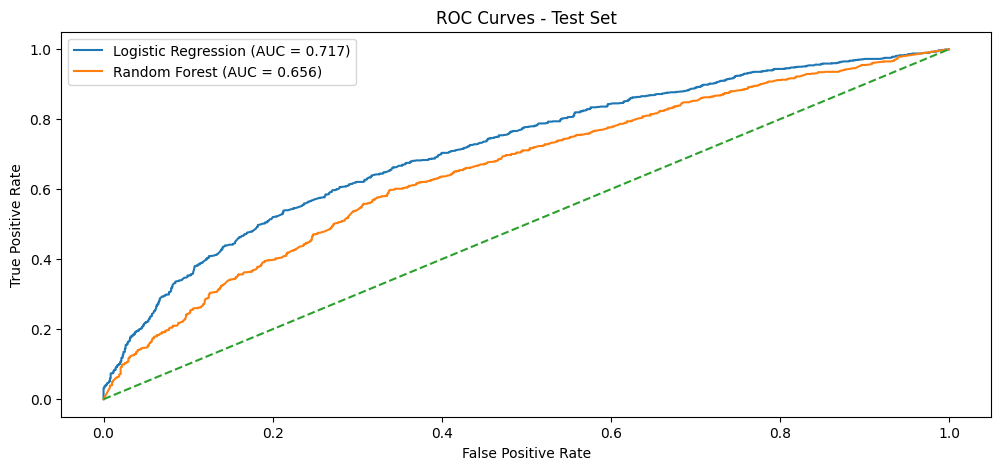

In [18]:
plt.figure(figsize=(12, 5))

# Logistic Regression
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")

# Random Forest
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Test Set")
plt.legend()
plt.show()

In [19]:
!jupyter nbconvert hw_1.ipynb --to html --embed-images

zsh:1: /Users/shantellluna/Downloads/Ethics-In-Artificial-Intelligence/.venv/bin/jupyter: bad interpreter: /Users/shantellluna/Downloads/Ethics_AI/.venv/bin/python3.13: no such file or directory
